## 1. Load data

In [ ]:
import pandas as pd
####Đọc file csv
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
####In bảng orders và iteams ra màn hình, hiển thị 5 dòng đầu tiên
print("ORDERS:", orders.shape)
print(orders.head())
print("ITEMS:", items.shape)
print(items.head())

ORDERS: (99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:0

## 2. Chuẩn hóa thời gian

In [ ]:
####Chuyển cột order_purchase_timestamp từ text sang datetimw
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
####Lấy riêng phần ngày (bỏ phần giờ)
orders["date"] = orders["order_purchase_timestamp"].dt.date
####In kết quả ra màn hình sau khi convert
print("AFTER TIME CONVERT:")
print(orders[["order_id", "date"]].head())

AFTER TIME CONVERT:
                           order_id        date
0  e481f51cbdc54678b7cc49136f2d6af7  2017-10-02
1  53cdb2fc8bc7dce0b6741e2150273451  2018-07-24
2  47770eb9100c2d0c44946d9cf07ec65d  2018-08-08
3  949d5b44dbf5de918fe9c16f97b45f8a  2017-11-18
4  ad21c59c0840e6cb83a9ceb5573f8159  2018-02-13


## 3. Tạo cột revenue

In [ ]:
####Tạo cột doanh thu cho từng dòng sản phẩm
items["revenue"] = items["price"] + items["freight_value"] ###Doanh thu = giá sản phẩm + phí ship
####Gom các đơn hàng trong order thành 1 dòng 
order_items = items.groupby("order_id").agg({
    "revenue": "sum",
    "order_item_id": "count",
    "seller_id": "nunique"
}).reset_index()
####Đặt lại tên cột
order_items.columns = [
    "order_id",
    "order_revenue",
    "item_count",
    "seller_count"
]

print("ORDER ITEMS AGG:")
print(order_items.head())
print(order_items.shape)

ORDER ITEMS AGG:
                           order_id  order_revenue  item_count  seller_count
0  00010242fe8c5a6d1ba2dd792cb16214          72.19           1             1
1  00018f77f2f0320c557190d7a144bdd3         259.83           1             1
2  000229ec398224ef6ca0657da4fc703e         216.87           1             1
3  00024acbcdf0a6daa1e931b038114c75          25.78           1             1
4  00042b26cf59d7ce69dfabb4e55b4fd9         218.04           1             1
(98666, 4)


## 4. Gom dữ liệu thanh toán theo đơn hàng

In [169]:
order_payments = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_installments": "mean"
}).reset_index()

print("PAYMENTS AGG:")
print(order_payments.head())

PAYMENTS AGG:
                           order_id  payment_value  payment_installments
0  00010242fe8c5a6d1ba2dd792cb16214          72.19                   2.0
1  00018f77f2f0320c557190d7a144bdd3         259.83                   3.0
2  000229ec398224ef6ca0657da4fc703e         216.87                   5.0
3  00024acbcdf0a6daa1e931b038114c75          25.78                   2.0
4  00042b26cf59d7ce69dfabb4e55b4fd9         218.04                   3.0


## 5. Gom chỉ số đánh giá theo đơn hàng

In [ ]:
order_reviews = reviews.groupby("order_id").agg({
    "review_score": "mean"
}).reset_index()

print("REVIEWS AGG:")
print(order_reviews.head())

REVIEWS AGG:
                           order_id  review_score
0  00010242fe8c5a6d1ba2dd792cb16214           5.0
1  00018f77f2f0320c557190d7a144bdd3           4.0
2  000229ec398224ef6ca0657da4fc703e           5.0
3  00024acbcdf0a6daa1e931b038114c75           4.0
4  00042b26cf59d7ce69dfabb4e55b4fd9           5.0


## 6. Merge 4 bảng dữ liệu thành 1 bảng 

In [ ]:
##Merge thành bảng orders
df = orders \
    .merge(order_items, on="order_id", how="left") \
    .merge(order_payments, on="order_id", how="left") \
    .merge(order_reviews, on="order_id", how="left") \
    .merge(customers, on="customer_id", how="left")
print("MERGED DF:")

print(df.shape)
print(df.head())

MERGED DF:
(99441, 19)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:

## 7. Tạo target revenue

In [172]:
df["revenue"] = df["order_revenue"]

print("TARGET STATS:")
print(df["revenue"].describe())

TARGET STATS:
count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: revenue, dtype: float64


## 8. Chuyển order_purchase_timestamp sang dạng ngày

In [174]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["date"] = df["order_purchase_timestamp"].dt.date

daily = df.groupby("date").agg({
    "revenue": "sum",
    "order_id": "count",
    "customer_id": "nunique",
    "review_score": "mean",
    "item_count": "sum"
}).reset_index()

print("DAILY DATA:")
print(daily.head())
print(daily.shape)

DAILY DATA:
         date  revenue  order_id  customer_id  review_score  item_count
0  2016-09-04   136.23         1            1           1.0         2.0
1  2016-09-05    75.06         1            1           1.0         1.0
2  2016-09-13     0.00         1            1           1.0         0.0
3  2016-09-15   143.46         1            1           1.0         3.0
4  2016-10-02   109.34         1            1           1.0         1.0
(634, 6)


## 9. FEATURE ENGINEERING

In [175]:
daily["date"] = pd.to_datetime(daily["date"])

daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["is_weekend"] = (daily["dayofweek"] >= 5).astype(int)

print(daily[["date","dayofweek","month","is_weekend"]].head())

        date  dayofweek  month  is_weekend
0 2016-09-04          6      9           1
1 2016-09-05          0      9           0
2 2016-09-13          1      9           0
3 2016-09-15          3      9           0
4 2016-10-02          6     10           1


## 10. Tạo đặc trưng trễ (lag feature)

In [ ]:
####Tạo đặc trưng trễ cách đây 1 ngày, 7 ngày và 30 ngày
daily["revenue_lag_1"] = daily["revenue"].shift(1)
daily["revenue_lag_7"] = daily["revenue"].shift(7)
daily["revenue_lag_30"] = daily["revenue"].shift(30)

print("LAG FEATURES:")
print(daily[["date","revenue","revenue_lag_1","revenue_lag_7"]].head(10))

LAG FEATURES:
        date   revenue  revenue_lag_1  revenue_lag_7
0 2016-09-04    136.23            NaN            NaN
1 2016-09-05     75.06         136.23            NaN
2 2016-09-13      0.00          75.06            NaN
3 2016-09-15    143.46           0.00            NaN
4 2016-10-02    109.34         143.46            NaN
5 2016-10-03    595.14         109.34            NaN
6 2016-10-04  11295.48         595.14            NaN
7 2016-10-05   9645.94       11295.48         136.23
8 2016-10-06   9131.23        9645.94          75.06
9 2016-10-07   8135.97        9131.23           0.00


## 11. Tính trung bình doanh thu 7 ngày và 30 ngày gần nhất

In [177]:
daily["revenue_ma_7"] = daily["revenue"].rolling(7).mean()
daily["revenue_ma_30"] = daily["revenue"].rolling(30).mean()

print("ROLLING FEATURES:")
print(daily[["date","revenue_ma_7","revenue_ma_30"]].head(10))

ROLLING FEATURES:
        date  revenue_ma_7  revenue_ma_30
0 2016-09-04           NaN            NaN
1 2016-09-05           NaN            NaN
2 2016-09-13           NaN            NaN
3 2016-09-15           NaN            NaN
4 2016-10-02           NaN            NaN
5 2016-10-03           NaN            NaN
6 2016-10-04   1764.958571            NaN
7 2016-10-05   3123.488571            NaN
8 2016-10-06   4417.227143            NaN
9 2016-10-07   5579.508571            NaN


## 12. Tạo feature revenue_growth

In [178]:
import numpy as np 
daily["revenue_growth"] = daily["revenue"].pct_change()

daily["revenue_growth"] = daily["revenue_growth"].replace(
    [np.inf, -np.inf], np.nan
)

## 13. Xóa các giá trị NAN trong bảng daily

In [245]:
daily = daily.dropna()

print("AFTER DROPNA:")
print(daily.shape)

AFTER DROPNA:
(589, 15)


## 14. Xây dựng mô hình Linear Regression dự báo doanh thu

In [227]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = [
    "item_count",
    "review_score",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_30",
    "revenue_ma_7",
    "revenue_ma_30",
    "revenue_growth",
    "dayofweek",
    "month",
    "is_weekend"
]

X = daily[features]
y = daily["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=False,
    test_size=0.2
)

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

## 15. Đánh giá mô hình Linear Regression

In [228]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

lr_mae = mean_absolute_error(y_test, y_pred)
lr_rmse = root_mean_squared_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("MAE:", round(lr_mae,3))
print("MSE:", round(lr_rmse, 3))
print("R²:", round(lr_r2,3))

MAE: 2842.799
MSE: 3703.436
R²: 0.925


## 16. Vẽ biểu đồ so sánh doanh thu thực tế và doanh thu dự đoán của mô hình Linear Regression

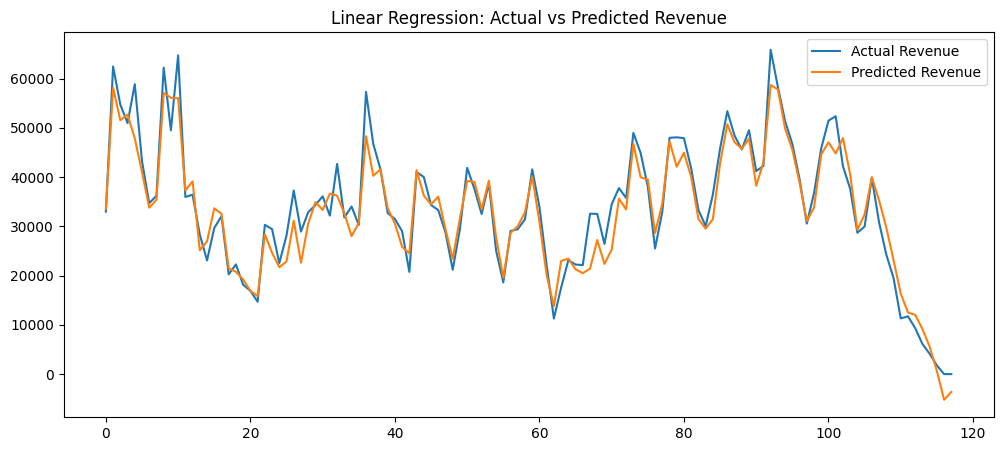

In [229]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual Revenue"
)

plt.plot(
    y_pred,
    label="Predicted Revenue"
)

plt.legend()
plt.title("Linear Regression: Actual vs Predicted Revenue")
plt.savefig("linear_regression_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [230]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

## 17. Xây dựng mô hình XGBoost dự báo doanh thu

In [248]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

features = [
    "item_count",
    "review_score",
    "revenue_lag_1",
    "revenue_lag_7",
    "revenue_lag_30",
    "revenue_ma_7",
    "revenue_ma_30",
    "revenue_growth",
    "dayofweek",
    "month",
    "is_weekend"
]

X = daily[features]
y = daily["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=False,
    test_size=0.2
)


xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)



## 18. Đánh giá mô hình XGBoost

In [249]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gxb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

print("MAE:", gxb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

MAE: 2643.687660056939
RMSE: 3495.4500144173803
R2: 0.9330210318093126


## 19. Vẽ biểu đồ so sánh doanh thu thực tế và doanh thu dự đoán của mô hình XGBoost

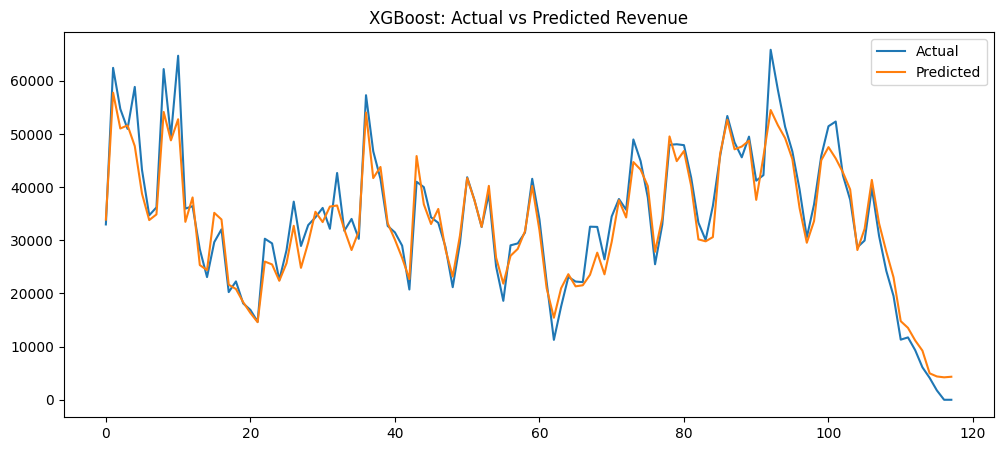

In [236]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("XGBoost: Actual vs Predicted Revenue")
plt.legend()
plt.savefig("xgboost_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 20. Xây dựng mô hình Random Forest dự báo doanh thu

In [250]:
from sklearn.ensemble import RandomForestRegressor
data = daily.copy()
data = data.sort_values("date")
data = data.drop(columns=["date"])

X = data.drop(columns=["revenue"])
y = data["revenue"]


split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


rf_model = RandomForestRegressor(
    n_estimators=200,     ###### số cây
    max_depth=10,         ###### độ sâu mỗi cây
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1             
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


## 21. Đánh giá mô hình Random Forest

In [251]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 3338.097590094363
RMSE: 4569.335532209611
R2: 0.885544053541377


## 22. Vẽ biểu đồ so sánh doanh thu thực tế và doanh thu dự đoán của mô hình Random Forest

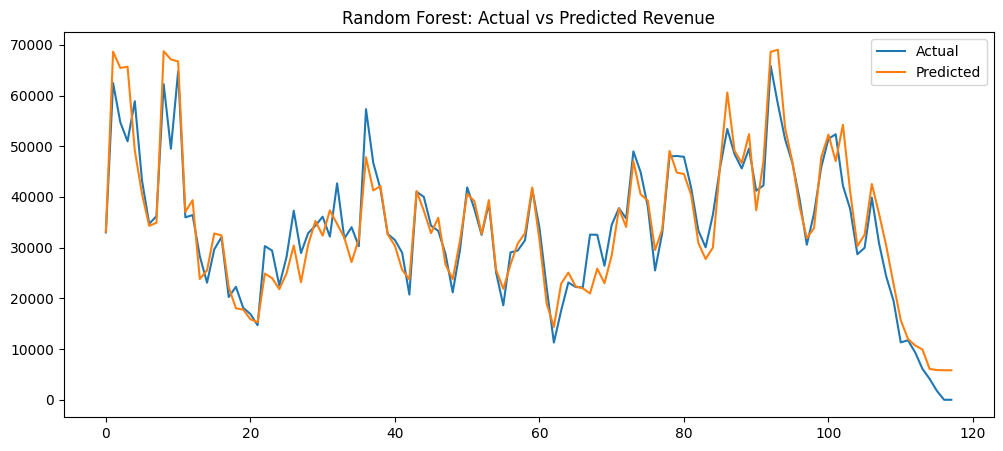

In [242]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted Revenue")
plt.savefig("random_forest_chart.png", dpi=300, bbox_inches="tight")
plt.show()

## 23. Đưa các chỉ số đánh giá của 3 mô hình vào các thư viện tương ứng

In [ ]:
lr_result = {
    "model": "Linear Regression",
    "MAE": lr_mae,
    "RMSE": lr_rmse,
    "R2": lr_r2
}


xgb_result = {
    "model": "XGBoost",
    "MAE": gxb_mae,
    "RMSE": xgb_rmse,
    "R2": xgb_r2
}

rf_result = {
    "model": "Ramdom Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "R2": rf_r2
}

## 24. Vẽ bảng mô tả các chỉ số đánh giá của 3 mô hình

In [224]:
import pandas as pd

results_df = pd.DataFrame([
    lr_result,
    xgb_result,
    rf_result
])

results_df

,model,MAE,RMSE,R2
0,Linear Regression,2842.798857,3703.436287,0.924813
1,XGBoost,2643.687660,3495.450014,0.933021
2,Ramdom Forest,3338.097590,4569.335532,0.885544


## 25. Sắp xếp bảng giảm dần theo chỉ số RMSE

In [243]:
results_df = results_df.sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
1,XGBoost,2643.687660,3495.450014,0.933021
0,Linear Regression,2842.798857,3703.436287,0.924813
2,Ramdom Forest,3338.097590,4569.335532,0.885544


## 26. Lưu bảng vào file model_coparision.csv

In [244]:
results_df.to_csv("model_comparison.csv", index=False)